# IoT Traffic Analysis — Device Type Classification (DL on Packet Windows)

This notebook is a **separate experiment** from the v4 "fingerprinting" notebook.

Goal (step 9):
- Build **packet windows** (mixing windows across devices)
- Train **DL (unmasked)** to predict **device_type** (broad classes)
- This removes the trivial *device-id fingerprinting* setup and makes the task closer to behavioral classification.

Notes:
- Uses **Scapy `PcapReader`** (true streaming) to avoid OOM.
- Uses a **device-level split** (train/test devices) to test generalization to unseen devices within the same types.
- The windowing strategy is **fixed packet-count windows** (e.g., 50 packets per sample). Later you can swap to time windows.


In [1]:
# 1) Imports & configuration
import os, glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from scapy.all import PcapReader

RANDOM_STATE = 43
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Paths
PCAP_DATA_GLOB = "unsw-dataset/pcaps/*.pcap"

# DL bytes and windowing
MAX_LEN = 500              # bytes per packet
PKTS_PER_WINDOW = 50       # packets per training sample (window)
STRIDE = 50                # 50 => non-overlapping; smaller => overlapping
MAX_WINDOWS_PER_DEVICE = 1500  # cap windows per device to keep runtime reasonable

# Training control
BATCH_SIZE = 128
EPOCHS = 5
SHUFFLE_BUF = 5000

print("MAX_LEN:", MAX_LEN, "| PKTS_PER_WINDOW:", PKTS_PER_WINDOW, "| STRIDE:", STRIDE)


2026-01-13 16:05:46.182707: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 16:05:46.649662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 16:05:49.415412: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


MAX_LEN: 500 | PKTS_PER_WINDOW: 50 | STRIDE: 50


## 2) Device → Type mapping

In [2]:
# Hardcoded device -> type mapping (same idea as v4)
device_to_type = {
    # camera / streamer
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    # sensors / meters
    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    # actuators / lights / plugs
    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    # hubs / infra
    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    # media / interactive
    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

# Collect pcaps and attach device/type
pcap_files = sorted(glob.glob(PCAP_DATA_GLOB))
if not pcap_files:
    raise FileNotFoundError(f"No pcaps found for pattern: {PCAP_DATA_GLOB}")

rows = []
for fp in pcap_files:
    dev = os.path.basename(fp).replace(".pcap", "")
    dev_type = device_to_type.get(dev, None)
    rows.append({"device": dev, "device_type": dev_type, "pcap_path": fp})

df_pcaps = pd.DataFrame(rows)
print("Total pcaps found:", len(df_pcaps))
print("Type coverage (pcaps):")
display(df_pcaps["device_type"].value_counts(dropna=False).to_frame("n_pcaps"))

# Filter to only mapped devices (so labels are defined)
df_pcaps = df_pcaps.dropna(subset=["device_type"]).reset_index(drop=True)
print("\nUsing mapped pcaps:", len(df_pcaps))
display(df_pcaps.head())


Total pcaps found: 26
Type coverage (pcaps):


,n_pcaps
device_type,
camera_streamer,8
sensor_meter,6
media_speaker_display,5
actuator_light_plug,4
hub_gateway_bridge,2
None,1



Using mapped pcaps: 25


,device,device_type,pcap_path
0,AmazonEcho_44650d56ccd3,media_speaker_display,unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap
1,AugustDoorBell_e076d03f00ae,camera_streamer,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
2,AwairAirQuality_70886b100fc6,sensor_meter,unsw-dataset/pcaps/AwairAirQuality_70886b100fc...
3,BelkinCamera_b4750eece5a9,camera_streamer,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
4,BelkinWemoMotionSensor_ec1a59832811,sensor_meter,unsw-dataset/pcaps/BelkinWemoMotionSensor_ec1a...


## 3) Device-level train/test split (avoid train/test leakage by device)

In [3]:
# Split by DEVICE (not windows) so test = unseen devices.
# Stratify by device_type at the device level.

devices = df_pcaps["device"].tolist()
types = df_pcaps["device_type"].tolist()

train_devs, test_devs = train_test_split(
    devices,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=types
)

train_set = set(train_devs)
test_set = set(test_devs)

df_train = df_pcaps[df_pcaps["device"].isin(train_set)].reset_index(drop=True)
df_test  = df_pcaps[df_pcaps["device"].isin(test_set)].reset_index(drop=True)

print("Train devices:", df_train["device"].nunique(), "| Test devices:", df_test["device"].nunique())
print("\nTrain type counts (devices):")
display(df_train["device_type"].value_counts().to_frame("n_devices"))
print("\nTest type counts (devices):")
display(df_test["device_type"].value_counts().to_frame("n_devices"))


Train devices: 17 | Test devices: 8

Train type counts (devices):


,n_devices
device_type,
camera_streamer,6
sensor_meter,4
media_speaker_display,3
actuator_light_plug,3
hub_gateway_bridge,1



Test type counts (devices):


,n_devices
device_type,
sensor_meter,2
camera_streamer,2
media_speaker_display,2
actuator_light_plug,1
hub_gateway_bridge,1


## 4) Window builder (streaming)

In [4]:
def packet_to_bytes(pkt, max_len=500):
    """Convert packet to fixed-length uint8 vector (no masking in this notebook)."""
    try:
        b = bytes(pkt)
        arr = np.frombuffer(b, dtype=np.uint8)
        if len(arr) >= max_len:
            arr = arr[:max_len]
        else:
            arr = np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=0)
        return arr
    except Exception:
        return None

# Encode device_type to integers
type_classes = sorted(df_pcaps["device_type"].unique())
type_to_idx = {t:i for i,t in enumerate(type_classes)}
idx_to_type = {i:t for t,i in type_to_idx.items()}
print("Type classes:", type_classes)

def iter_windows(df_subset, max_len=500, pkts_per_window=50, stride=50, max_windows_per_device=1500):
    """Yield (window_tensor, y_idx) where window_tensor is float32 [pkts_per_window, max_len]."""
    order = df_subset.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

    for _, row in order.iterrows():
        y_idx = type_to_idx[row["device_type"]]
        fp = row["pcap_path"]

        buf = []
        produced = 0

        with PcapReader(fp) as pcap:
            for pkt in pcap:
                arr = packet_to_bytes(pkt, max_len=max_len)
                if arr is None:
                    continue
                buf.append(arr)

                if len(buf) == pkts_per_window:
                    window = np.stack(buf, axis=0).astype(np.float32) / 255.0
                    yield window, np.int64(y_idx)
                    produced += 1

                    if produced >= max_windows_per_device:
                        break

                    # slide
                    if stride >= pkts_per_window:
                        buf = []
                    else:
                        buf = buf[stride:]

# sanity check
g = iter_windows(df_train, max_len=MAX_LEN, pkts_per_window=PKTS_PER_WINDOW, stride=STRIDE, max_windows_per_device=1)
x, y = next(g)
print("Sanity sample shape:", x.shape, "| label:", int(y), "| type:", idx_to_type[int(y)])


Type classes: ['actuator_light_plug', 'camera_streamer', 'hub_gateway_bridge', 'media_speaker_display', 'sensor_meter']
Sanity sample shape: (50, 500) | label: 0 | type: actuator_light_plug


## 5) tf.data datasets (train/test windows)

In [5]:
def make_window_dataset(df_subset, repeat=False, shuffle_buf=5000):
    output_signature = (
        tf.TensorSpec(shape=(PKTS_PER_WINDOW, MAX_LEN), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: iter_windows(
            df_subset,
            max_len=MAX_LEN,
            pkts_per_window=PKTS_PER_WINDOW,
            stride=STRIDE,
            max_windows_per_device=MAX_WINDOWS_PER_DEVICE
        ),
        output_signature=output_signature
    )

    if shuffle_buf and shuffle_buf > 0:
        ds = ds.shuffle(shuffle_buf, seed=RANDOM_STATE, reshuffle_each_iteration=True)

    if repeat:
        ds = ds.repeat()

    ds = ds.map(lambda x, y: (tf.expand_dims(x, axis=-1), y), num_parallel_calls=1)
    ds = ds.batch(BATCH_SIZE).prefetch(1)
    return ds

ds_train = make_window_dataset(df_train, repeat=True, shuffle_buf=SHUFFLE_BUF)
ds_test  = make_window_dataset(df_test,  repeat=False, shuffle_buf=0)

# Upper bound steps; cap to keep runtime reasonable
max_train_windows = df_train["device"].nunique() * MAX_WINDOWS_PER_DEVICE
steps_per_epoch = int(np.ceil(max_train_windows / BATCH_SIZE))
steps_per_epoch = min(500, steps_per_epoch)

print("Upper bound train windows:", max_train_windows)
print("steps_per_epoch:", steps_per_epoch, "| batch_size:", BATCH_SIZE)


Upper bound train windows: 25500
steps_per_epoch: 200 | batch_size: 128


2026-01-13 16:05:51.092659: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 6) DL model (unmasked) and training

In [6]:
def make_window_cnn(pkts_per_window=50, max_len=500, n_classes=5):
    model = Sequential([
        Input(shape=(pkts_per_window, max_len, 1)),
        Conv2D(16, (3, 7), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 7), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tf.keras.backend.clear_session()
model = make_window_cnn(PKTS_PER_WINDOW, MAX_LEN, len(type_classes))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 494, 16)    │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 247, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 241, 32)    │        10,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 120, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 42240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,406,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,418,629 (20.67 MB)

 Trainable params: 5,418,629 (20.67 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
t0 = time.time()
hist = model.fit(
    ds_train,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    verbose=1
)
train_time = time.time() - t0

loss, acc = model.evaluate(ds_test, verbose=0)
print(f"DL (unmasked) — device_type Accuracy: {acc:.4f}")
print(f"Train time: {train_time:.2f}s")


Epoch 1/5


2026-01-13 16:06:02.917176: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 393 of 5000
2026-01-13 16:06:22.917667: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 1160 of 5000
2026-01-13 16:06:32.924312: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 1582 of 5000
2026-01-13 16:06:52.910160: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 2508 of 5000
2026-01-13 16:07:02.913683: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 2983 of 5000
2026-01-13 16:07:12.917333: I tensor

200/200 ━━━━━━━━━━━━━━━━━━━━ 835s 4s/step - accuracy: 0.8995 - loss: 0.3332
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 607s 3s/step - accuracy: 0.9895 - loss: 0.0372
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 744s 4s/step - accuracy: 0.9968 - loss: 0.0121
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 773s 4s/step - accuracy: 0.9991 - loss: 0.0042
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 700s 4s/step - accuracy: 0.9992 - loss: 0.0032
DL (unmasked) — device_type Accuracy: 0.3158
Train time: 3660.27s


2026-01-13 17:11:21.263135: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## 7) Diagnostics: confusion matrix + learning curves

2026-01-13 17:15:58.563827: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


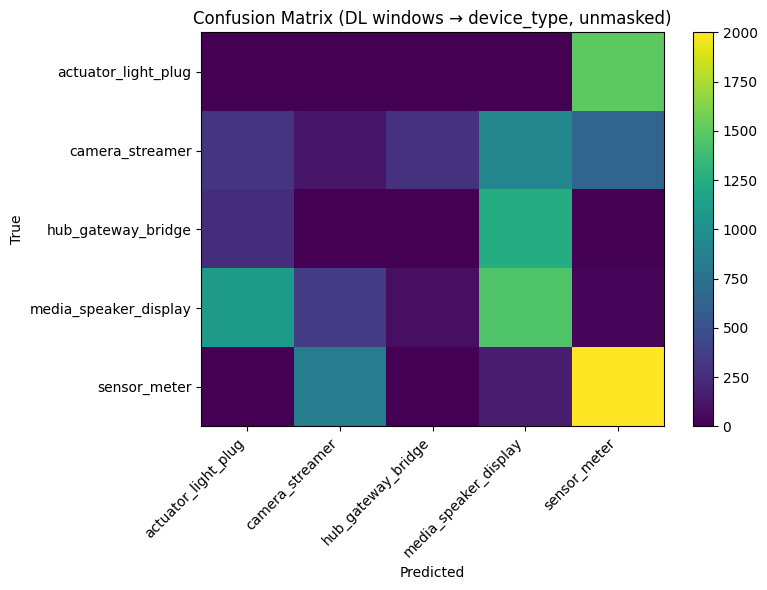


Classification report (sampled test batches):
                       precision    recall  f1-score   support

  actuator_light_plug       0.00      0.00      0.00      1500
      camera_streamer       0.09      0.05      0.06      2282
   hub_gateway_bridge       0.00      0.00      0.00      1500
media_speaker_display       0.39      0.48      0.43      3000
         sensor_meter       0.48      0.67      0.56      3000

             accuracy                           0.32     11282
            macro avg       0.19      0.24      0.21     11282
         weighted avg       0.25      0.32      0.27     11282



In [8]:
y_true, y_pred = [], []

for xb, yb in ds_test.take(200):  # cap batches
    probs = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(type_classes))))

plt.figure(figsize=(8,6))
plt.imshow(cm, aspect="auto")
plt.xticks(range(len(type_classes)), type_classes, rotation=45, ha="right")
plt.yticks(range(len(type_classes)), type_classes)
plt.title("Confusion Matrix (DL windows → device_type, unmasked)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

print("\nClassification report (sampled test batches):")
print(classification_report(y_true, y_pred, target_names=type_classes))


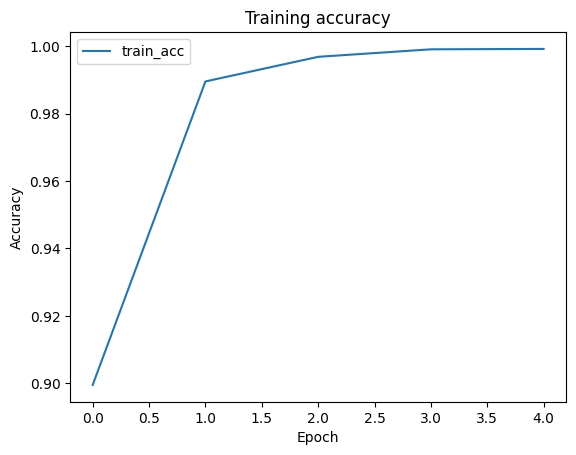

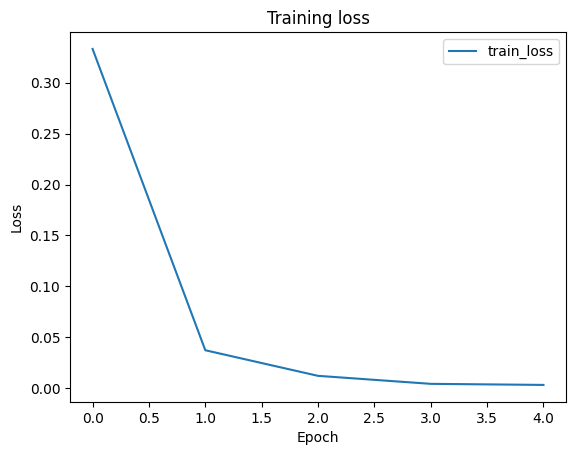

In [9]:
plt.figure()
plt.plot(hist.history.get("accuracy", []), label="train_acc")
plt.title("Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist.history.get("loss", []), label="train_loss")
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Next steps (not implemented here)

1) Add **DL-MASKED**: apply the same masking as v4 inside `packet_to_bytes(...)`.
2) Add ML/ML-masked on window-aggregated flows to compare fairly.
3) Swap fixed packet windows for time windows if desired.
